# Generative Adversarial Network (GAN) for CelebA Faces

This notebook demonstrates how to build and train a Generative Adversarial Network (GAN) to generate realistic human faces using the CelebA dataset. We will define a discriminator and a generator network, combine them into a GAN model, and train it using Keras.

In [ ]:
#getting the CelebA data
!mkdir celeba_gan
!gdown --id 1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684 -O celeba_gan/data.zip
!unzip -qq celeba_gan/data.zip -d celeba_gan

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684
From (redirected): https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684&confirm=t&uuid=3b7fec9a-21e5-4b5f-94db-18c235ff2f19
To: /content/celeba_gan/data.zip
100% 1.44G/1.44G [00:23<00:00, 60.9MB/s]


## 1. Data Loading and Preparation

First, we download and extract the CelebA dataset, which contains a large collection of celebrity face images. We use `gdown` to download the dataset from Google Drive and `unzip` to extract it.

In [ ]:
from tensorflow import keras

dataset = keras.preprocessing.image_dataset_from_directory(
    "celeba_gan",
    batch_size=32,
    image_size=(64, 64),
    label_mode=None
)

Found 202599 files.


### 1.1 Creating a Keras `tf.data.Dataset`

We load the images into a `tf.data.Dataset` using `keras.preprocessing.image_dataset_from_directory`. This utility automatically creates a dataset from images in a directory structure. We configure it to produce batches of 64x64 pixel images without labels, as GANs typically don't require labels for image generation.

In [ ]:
#rescaling the images
dataset = dataset.map(lambda x: x / 255.)

### 1.2 Image Normalization

GANs often perform better when input images are normalized to a specific range. Here, we rescale the pixel values from the default [0, 255] range to [0, 1] by dividing each pixel by 255. This helps stabilize the training process.

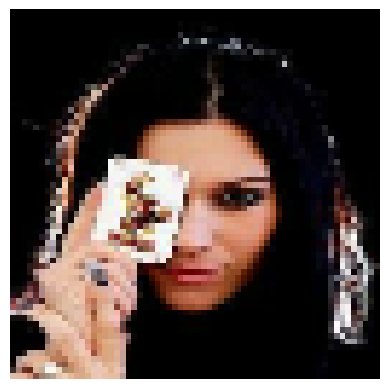

In [ ]:
#displaying the first image
import matplotlib.pyplot as plt
for x in dataset:
  plt.axis("off")
  plt.imshow((x.numpy() * 255).astype("int32")[31])
  break

### 1.3 Visualizing Sample Images

To ensure our data loading and preprocessing steps are correct, we display one of the images from the dataset. This helps us verify that the images are correctly loaded and scaled.

In [ ]:
##The Gan discriminator network
from tensorflow.keras import layers

discriminator = keras.Sequential(
    [
        keras.Input(shape=(64, 64, 3)),
        layers.Conv2D(64, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha = 0.2),
        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha = 0.2),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="discriminator",
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


## 2. Model Architecture: Discriminator

The discriminator is a convolutional neural network (CNN) that tries to distinguish between real images (from the CelebA dataset) and fake images (generated by the generator). It's trained to output a probability indicating whether an image is real or fake.

Our discriminator uses several `Conv2D` layers with `LeakyReLU` activation, followed by `Flatten`, `Dropout`, and a `Dense` layer with `sigmoid` activation for binary classification.

In [ ]:
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,801 (1.54 MB)

 Trainable params: 404,801 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

### 2.1 Discriminator Summary

This summary provides an overview of the discriminator's architecture, including the output shape of each layer and the total number of trainable parameters.

In [ ]:
#The GAN generator network
latent_dim = 128

generator = keras.Sequential(
    [
        keras.Input(shape=(latent_dim,)),
        layers.Dense(8 * 8 * 128),
        layers.Reshape((8, 8, 128)),
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(256, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(512, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(3, kernel_size=5, padding="same", activation="sigmoid"),
    ],
    name="generator",
)

## 3. Model Architecture: Generator

The generator is also a convolutional neural network (CNN), but its role is to create realistic-looking images from random noise (latent vectors). It learns to produce images that can fool the discriminator.

Our generator starts with a `Dense` layer to project the latent vector into a higher-dimensional space, followed by `Reshape` and several `Conv2DTranspose` (deconvolutional) layers with `LeakyReLU` activation to upsample and generate an image. The final `Conv2D` layer uses a `sigmoid` activation to output pixel values in the [0, 1] range.

In [ ]:
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 8192)           │     1,056,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 256)    │       524,544 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 512)    │     2,097,664 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64, 64, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 3)      │        38,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,979,651 (15.18 MB)

 Trainable params: 3,979,651 (15.18 MB)

 Non-trainable params: 0 (0.00 B)

### 3.1 Generator Summary

This summary provides an overview of the generator's architecture, including the output shape of each layer and the total number of trainable parameters.

In [ ]:
#The GAN model
import tensorflow as tf

class GAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super(GAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(GAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim))
        generated_images = self.generator(random_latent_vectors)
        combined_images = tf.concat([generated_images, real_images], axis=0)
        labels = tf.concat(
            [tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))], axis=0)
        labels += 0.05 * tf.random.uniform(tf.shape(labels))
        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim))
        misleading_labels = tf.zeros((batch_size, 1))
        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(
            zip(grads, self.generator.trainable_weights)
        )
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return {"d_loss": self.d_loss_metric.result(), "g_loss": self.g_loss_metric.result()}

## 4. GAN Model Implementation

We define a custom `GAN` class by inheriting from `keras.Model`. This class encapsulates the training logic for both the discriminator and the generator. The `train_step` method handles:

1.  **Generating fake images**: The generator creates images from random noise.
2.  **Training the discriminator**: The discriminator is trained to classify both real and fake images.
3.  **Training the generator**: The generator is trained to produce images that the discriminator classifies as real.

In [ ]:
#A callback that samples generated image during training
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal(shape=(self.num_img, self.latent_dim))
        generated_images = self.model.generator(random_latent_vectors)
        generated_images *= 255
        generated_images.numpy()
        for i in range(self.num_img):
            img = keras.preprocessing.image.array_to_img(generated_images[i])
            img.save(f"/content/drive/MyDrive/Colab Notebooks/GANOutputs/generated_img_{epoch:03d}_{i}.png")

## 5. GAN Monitor Callback

To observe the progress of the GAN during training, we implement a custom Keras callback called `GANMonitor`. This callback generates a few sample images from the generator at the end of each epoch and saves them to a specified directory. This allows us to visually track how the generated images evolve over time.

In [ ]:
#compiling and training the GAN
epochs = 30

gan = GAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

gan.fit(
    dataset, epochs=epochs, callbacks=[GANMonitor(num_img=10, latent_dim=latent_dim)]
)

Epoch 1/30
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 1825s 284ms/step - d_loss: 0.6071 - g_loss: 1.2427
Epoch 2/30
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 1791s 283ms/step - d_loss: 0.6558 - g_loss: 1.0511
Epoch 3/30
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 1791s 283ms/step - d_loss: 0.6795 - g_loss: 0.9453
Epoch 4/30
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 1791s 283ms/step - d_loss: 0.6549 - g_loss: 1.0059
Epoch 5/30
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 1791s 283ms/step - d_loss: 0.6171 - g_loss: 1.1193
Epoch 6/30
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 1791s 283ms/step - d_loss: 0.6287 - g_loss: 1.0606
Epoch 7/30
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 1791s 283ms/step - d_loss: 0.6561 - g_loss: 0.9716
Epoch 8/30
3238/6332 ━━━━━━━━━━━━━━━━━━━━ 14:35 283ms/step - d_loss: 0.6717 - g_loss: 0.9140

## 6. Training the GAN

Finally, we compile and train our GAN model. We use the Adam optimizer for both the discriminator and generator, and `BinaryCrossentropy` as the loss function. The training runs for a specified number of epochs, with the `GANMonitor` callback saving generated images periodically.

# GAN ouptus from epoch 5



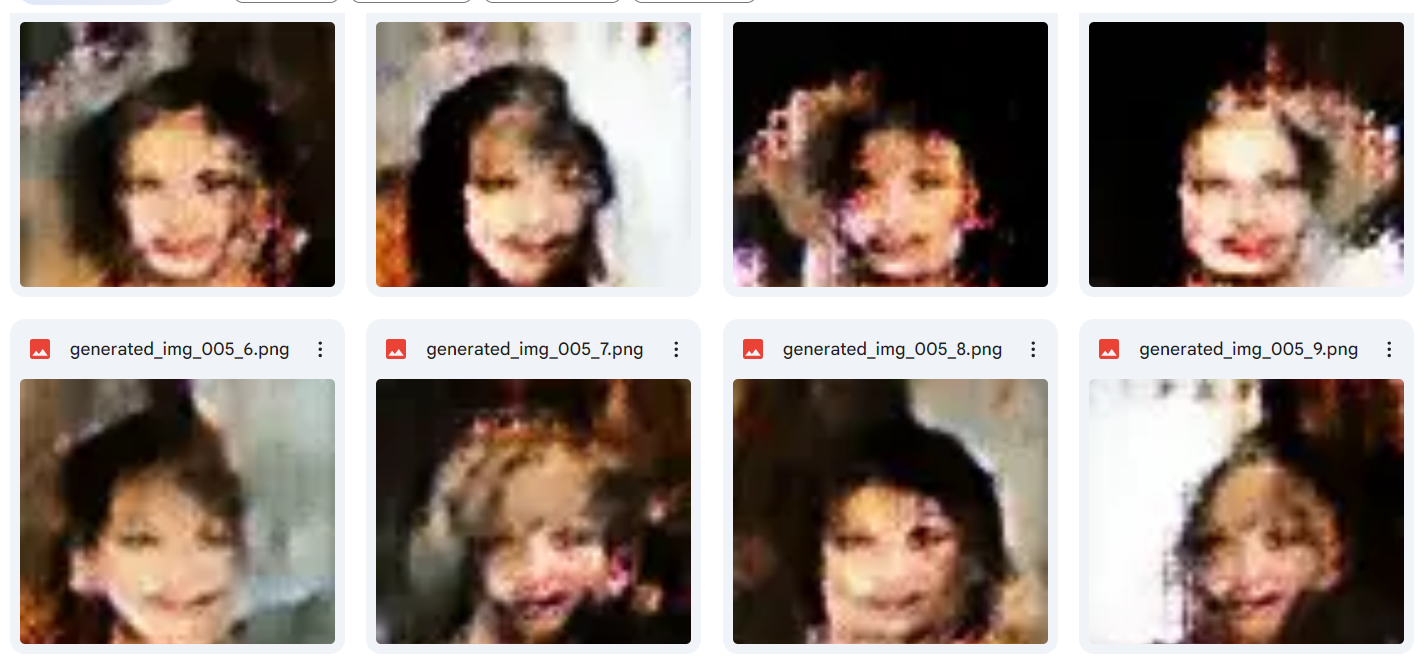

Due to limited compute resources, the model could not be fully trained for 100 epochs. The provided outputs are from epoch 5, as compute resources ran out around epoch 7.